# 1st-class men

The second pocket from `error_analysis.ipynb`: 122 passengers, 45 survived, and the baseline
predicts "died" for all of them — so it is right 63% of the time and those 45 are its errors.
On the test set that is 57 rows and about 21 errors.

The shape of the problem is the opposite of 3rd-class women. There, the rule was guessing at
exactly 50% and one subgroup sat at 11%. Here the rule is already 63% right, so a subgroup only
pays if it survives at **above** 50% — and it has to be big enough for that to mean something.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

from preprocessing import build_preprocessing_pipeline
from train import MODELS

raw = pd.read_csv("data/train.csv")
df = raw.copy()
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["TicketGroupSize"] = df.groupby("Ticket")["Ticket"].transform("size")
females_per_ticket = df.assign(f=(df["Sex"] == "female").astype(int)).groupby("Ticket")["f"].transform("sum")
children_per_ticket = df.assign(k=(df["Age"] < 15).astype(float)).groupby("Ticket")["k"].transform("sum")

pocket = df[(df["Sex"] == "male") & (df["Pclass"] == 1)].copy()
pocket["Deck"] = pocket["Cabin"].str[0]
pocket["CabinNumber"] = pd.to_numeric(pocket["Cabin"].str.extract(r"(\d+)", expand=False), errors="coerce")
pocket["WithFemale"] = (females_per_ticket[pocket.index] > 0).astype(int)
pocket["WithChild"] = (children_per_ticket[pocket.index].fillna(0) > 0).astype(int)
pocket["IsMaster"] = pocket["Title"].eq("Master").astype(int)
pocket["AgeBand"] = pd.cut(pocket["Age"], [0, 15, 30, 40, 50, 100])
pocket["FareBand"] = pd.qcut(pocket["Fare"], 3, labels=["low", "mid", "high"])

print(f"n={len(pocket)}, survived={pocket['Survived'].sum()} ({pocket['Survived'].mean():.1%})")
print(f"the baseline predicts died for all of them, so it scores "
      f"{1 - pocket['Survived'].mean():.3f} here")

n=122, survived=45 (36.9%)
the baseline predicts died for all of them, so it scores 0.631 here


## Candidate signals, with uncertainty

The 0.5 line is the one that matters. A bar below it is a group the rule already handles; only a
bar **above** 0.5, wide enough to be real, is worth anything.

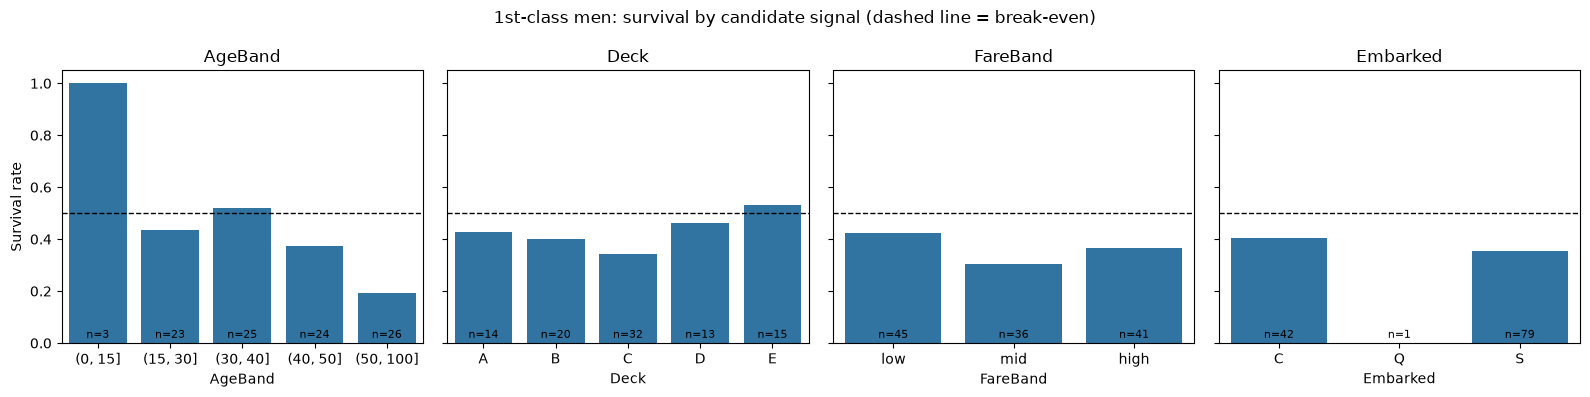

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, col, order in zip(
    axes,
    ["AgeBand", "Deck", "FareBand", "Embarked"],
    [None, ["A", "B", "C", "D", "E"], ["low", "mid", "high"], ["C", "Q", "S"]],
):
    sns.barplot(data=pocket, x=col, y="Survived", order=order, ax=ax, errorbar=None)
    counts = pocket[col].value_counts()
    levels = order if order else [level for level in pocket[col].cat.categories if counts.get(level, 0)]
    for i, level in enumerate(levels):
        ax.text(i, 0.02, f"n={counts.get(level, 0)}", ha="center", fontsize=8)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_ylabel("Survival rate")
plt.suptitle("1st-class men: survival by candidate signal (dashed line = break-even)")
plt.tight_layout()
plt.show()

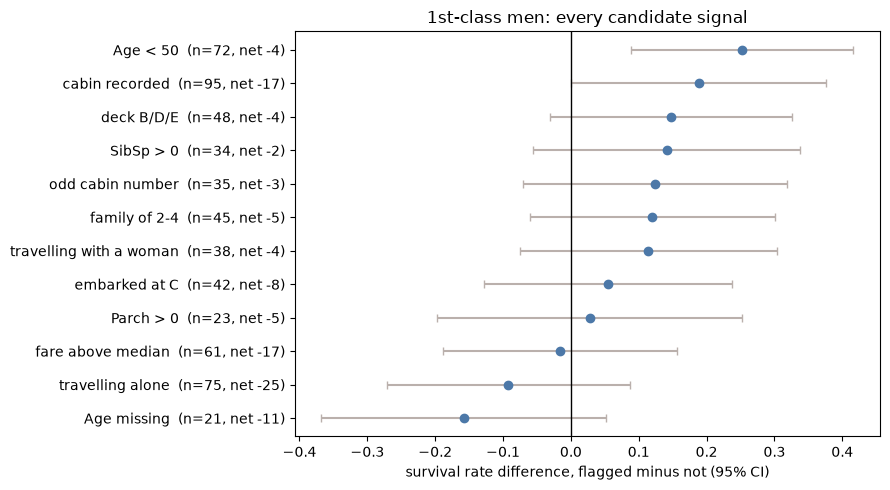

,n_flagged,rate_in,gap,se,net_if_flipped
signal,,,,,
Age missing,21,0.238,-0.158,0.107,-11
travelling alone,75,0.333,-0.092,0.091,-25
fare above median,61,0.361,-0.016,0.088,-17
Parch > 0,23,0.391,0.028,0.115,-5
embarked at C,42,0.405,0.055,0.094,-8
travelling with a woman,38,0.447,0.114,0.097,-4
family of 2-4,45,0.444,0.120,0.092,-5
odd cabin number,35,0.457,0.124,0.099,-3
SibSp > 0,34,0.471,0.141,0.100,-2


In [3]:
# every binary candidate at once, with a 95% interval on the gap
candidates = {
    "travelling with a woman": pocket["WithFemale"].eq(1),
    "travelling with a child": pocket["WithChild"].eq(1),
    "cabin recorded": pocket["Cabin"].notna(),
    "deck B/D/E": pocket["Deck"].isin(list("BDE")),
    "odd cabin number": pocket["CabinNumber"].mod(2).eq(1),
    "travelling alone": pocket["FamilySize"].eq(1),
    "family of 2-4": pocket["FamilySize"].between(2, 4),
    "Parch > 0": pocket["Parch"].gt(0),
    "SibSp > 0": pocket["SibSp"].gt(0),
    "Age < 50": pocket["Age"].lt(50),
    "Age missing": pocket["Age"].isna(),
    "embarked at C": pocket["Embarked"].eq("C"),
    "fare above median": pocket["Fare"].gt(pocket["Fare"].median()),
}
rows = []
for name, mask in candidates.items():
    inside, outside = pocket.loc[mask, "Survived"], pocket.loc[~mask, "Survived"]
    if len(inside) < 5 or len(outside) < 5:
        continue
    rows.append({
        "signal": name, "n_flagged": len(inside), "rate_in": inside.mean(),
        "gap": inside.mean() - outside.mean(),
        "se": np.sqrt(inside.var(ddof=1) / len(inside) + outside.var(ddof=1) / len(outside)),
        # the rule says "died", so flipping this group gains survivors minus deaths
        "net_if_flipped": int(inside.sum() - (1 - inside).sum()),
    })
effects = pd.DataFrame(rows).set_index("signal").sort_values("gap")

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(effects["gap"], np.arange(len(effects)), xerr=1.96 * effects["se"],
            fmt="o", color="#4c78a8", ecolor="#bab0ac", capsize=3)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(np.arange(len(effects)),
              [f"{i}  (n={n}, net {v:+d})" for i, n, v in
               zip(effects.index, effects["n_flagged"], effects["net_if_flipped"])])
ax.set_xlabel("survival rate difference, flagged minus not (95% CI)")
ax.set_title("1st-class men: every candidate signal")
plt.tight_layout()
plt.show()
effects.round(3)

## Interactions

No single signal clears the line, so the question is whether two together can. Each cell shows the
survival rate; a cell above 0.50 is a group the rule gets wrong more often than right.

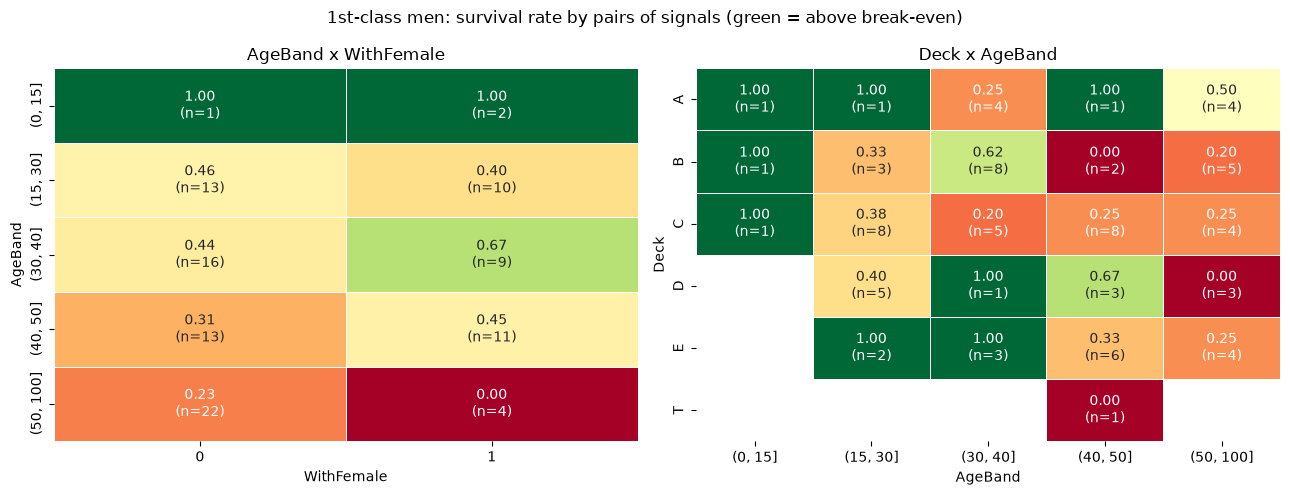

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (rows_by, cols_by) in zip(axes, [("AgeBand", "WithFemale"), ("Deck", "AgeBand")]):
    rate = pocket.pivot_table(index=rows_by, columns=cols_by, values="Survived",
                              aggfunc="mean", observed=True)
    counts = pocket.pivot_table(index=rows_by, columns=cols_by, values="Survived",
                                aggfunc="size", observed=True)
    labels = rate.map(lambda v: "" if pd.isna(v) else f"{v:.2f}") + counts.map(
        lambda n: "" if pd.isna(n) else f"\n(n={int(n)})")
    sns.heatmap(rate, annot=labels, fmt="", cmap="RdYlGn", vmin=0, vmax=1, center=0.5,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(f"{rows_by} x {cols_by}")
plt.suptitle("1st-class men: survival rate by pairs of signals (green = above break-even)")
plt.tight_layout()
plt.show()

In [5]:
# the best combinations found, scored in rows, with the noise on that score
combos = {
    "with a woman, under 50": pocket["WithFemale"].eq(1) & pocket["Age"].lt(50),
    "deck B/D/E, under 50": pocket["Deck"].isin(list("BDE")) & pocket["Age"].lt(50),
    "family of 2-4, under 50": pocket["FamilySize"].between(2, 4) & pocket["Age"].lt(50),
    "with a woman and a cabin": pocket["WithFemale"].eq(1) & pocket["Cabin"].notna(),
    "age 30-40": pocket["Age"].between(30, 40),
    "not alone, under 50": pocket["FamilySize"].gt(1) & pocket["Age"].lt(50),
}
scored = []
for name, mask in combos.items():
    sub = pocket[mask]
    net = int(sub["Survived"].sum() - (1 - sub["Survived"]).sum())
    scored.append({"combination": name, "n": len(sub), "survival": round(sub["Survived"].mean(), 3),
                   "net_rows": net, "noise": round(np.sqrt(len(sub)), 1)})
pd.DataFrame(scored).set_index("combination")

,n,survival,net_rows,noise
combination,,,,
"with a woman, under 50",29,0.552,3,5.4
"deck B/D/E, under 50",33,0.576,5,5.7
"family of 2-4, under 50",35,0.514,1,5.9
with a woman and a cabin,32,0.500,0,5.7
age 30-40,26,0.500,0,5.1
"not alone, under 50",36,0.500,0,6.0


## What a model with everything already achieves

Before hunting further it is worth knowing the ceiling. `gradient_boosting` has every engineered
feature in the project and is free to carve this pocket however it likes.

In [6]:
X, y = raw.drop(columns=["Survived"]), raw["Survived"]
config = yaml.safe_load(open("configs/gradient_boosting.yaml"))
model = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(config["features"])),
    ("model", MODELS[config["model"]](**config["params"])),
])
oof = pd.Series(index=X.index, dtype=int)
for train_idx, test_idx in StratifiedKFold(5, shuffle=True, random_state=42).split(X, y):
    oof.iloc[test_idx] = model.fit(X.iloc[train_idx], y.iloc[train_idx]).predict(X.iloc[test_idx])

mask = (X["Sex"] == "male") & (X["Pclass"] == 1)
print(f"baseline (predict died for all):  {(y[mask] == 0).mean():.3f}   {int((y[mask] == 0).sum())}/122")
print(f"gradient_boosting, out-of-fold:   {(oof[mask] == y[mask]).mean():.3f}   "
      f"{int((oof[mask] == y[mask]).sum())}/122")
print(f"it calls {int(oof[mask].sum())} of them survivors and nets "
      f"{int((oof[mask] == y[mask]).sum()) - int((y[mask] == 0).sum()):+d} rows")

baseline (predict died for all):  0.631   77/122
gradient_boosting, out-of-fold:   0.656   80/122
it calls 37 of them survivors and nets +3 rows


depth 1: 0.629 +/- 0.070   (predicting 'died' for all 122 = 0.631)
depth 2: 0.602 +/- 0.078   (predicting 'died' for all 122 = 0.631)
depth 3: 0.598 +/- 0.078   (predicting 'died' for all 122 = 0.631)


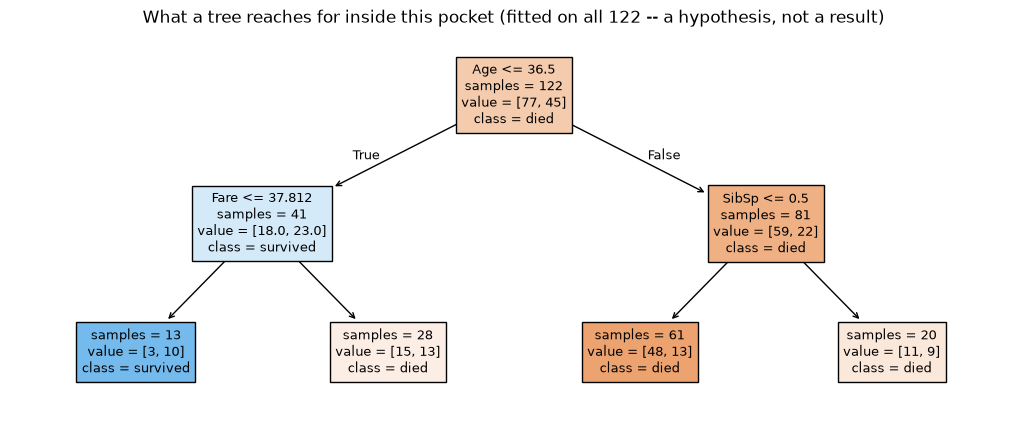

In [7]:
# and a tree given only this pocket, which is the most favourable case possible
features = pocket[["Age", "Fare", "SibSp", "Parch", "FamilySize", "TicketGroupSize",
                   "WithFemale", "WithChild", "CabinNumber"]].copy()
features["Age"] = features["Age"].fillna(pocket["Age"].median())
features["CabinNumber"] = features["CabinNumber"].fillna(-1)
features["HasCabin"] = pocket["Cabin"].notna().astype(int)
target = pocket["Survived"]

for depth in (1, 2, 3):
    scores = cross_val_score(
        DecisionTreeClassifier(max_depth=depth, min_samples_leaf=10, random_state=0),
        features, target, scoring="accuracy",
        cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0),
    )
    print(f"depth {depth}: {scores.mean():.3f} +/- {scores.std():.3f}   "
          f"(predicting 'died' for all 122 = 0.631)")

fitted = DecisionTreeClassifier(max_depth=2, min_samples_leaf=10, random_state=0).fit(features, target)
plt.figure(figsize=(13, 5))
plot_tree(fitted, feature_names=features.columns.tolist(), class_names=["died", "survived"],
          filled=True, impurity=False, fontsize=9)
plt.title("What a tree reaches for inside this pocket (fitted on all 122 -- a hypothesis, not a result)")
plt.show()

## Conclusions

**This pocket is a genuine coin flip, and that is a different problem from the last one.**

3rd-class women looked hopeless at exactly 50% but contained a 27-row subgroup surviving at 11% --
four standard errors from the line, so flipping it paid immediately. 1st-class men have no such
subgroup. The best combination found is *deck B/D/E and under 50*: 33 passengers surviving at 57.6%,
worth **+5 rows give or take 6**. The noise is larger than the signal.

**The ceiling is measurable and it is low.** `gradient_boosting`, with every feature in the project
and complete freedom to carve, scores 0.656 against the baseline's 0.631 -- **three rows** across the
whole pocket, while betting "survived" on 37 of the 122. A tree given nothing but this pocket does
worse than the constant at every depth. That is what trying hard looks like here.

**The tested-and-failed list is worth keeping**, because each had a real story:

- *Cabin side.* Odd and even cabin numbers were opposite sides of the ship, and the two officers
  loading boats applied "women and children first" differently -- Lightoller to the letter on the
  port side, Murdoch admitting men on the starboard. If any hypothesis should have worked, this one.
  45.7% vs 39.0%, interval straddling zero.
- *Deck.* A-deck was closest to the boats. Decks A through E span 34% to 53% with 13-32 rows each --
  no ordering, and every interval overlaps.
- *Travelling with women or children.* The story is that a man escorting family was let aboard, or
  that he stayed behind. Both are plausible and the data picks neither: 44.7% with, 33.3% without,
  worth -4 rows.

**What actually decided it was not in the manifest.** Whether a 1st-class man lived came down to
where he was standing when a particular boat was lowered and which officer was loading it. The
passenger list does not record that, and no amount of feature engineering will recover it.

The honest read: skip this pocket. The remaining errors in the project are not evenly winnable, and
this is the half that isn't.